In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/ELG/alltiles_ELGzinfo.fits'))
print(len(zbest))

179361


In [4]:
zbest[:1]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,NUM_TILEID,FIRST_FIBER,LAST_FIBER,NUM_FIBER,EXPS,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,subset,elgqso_weight,TARGETS
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,int16,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,float64,str7
39627623046844543,8795.245060801506,1094.1371845646356 .. 24.450323678084732,0.11228737991070209,3.855171846007255e-06,0,7909,GALAXY,,10,2762.2102209329605,0,1,0,431,431,165,0,66.55048231931394,-6.64515347019701,0.0,0.0,2020.9624,5400.0,1152922329240568578,1,TGT,33.025463,-352.86115,16959,2000,0.3429830310216254,7,SER,6.263769,7.8084993,9.722772,366.74835,103.14569,47.797363,0,,0.0,0.0,0.0,0.0,0.054453425,3.400604,6.3455386,1.5796138,1.9691681,2.4519143,1.5796138,1.9691681,2.4519143,0,1.8363522,1.6817222,0.25503045,-0.25395837,S,1152922329240568578,262148,0,2000,1,9010,291820,0664m067,4223,1e+20,1e+20,1e+20,1e+20,0,0,0,999999,2,33.017,-352.759,-0.0025,0.004999999999999999,66.55049218897548,-6.645134846478134,20201220,69037,59204.1933784,80612,4,0.0035355339059327377,0.006244997998398398,20201220,20201220,1,69037,69040,4,80612,80612,1,165,165,1,"69037,69038,69039,69040",152.19999885559082,256.0999984741211,330.0,107.12174034118652,205.22063064575195,291.6577377319336,171.97615742497146,2242.291923522949,14.19109775684774,12.576469212770462,20201220,1.0,BGS+MWS


In [5]:
mask = zbest['subset']=='deep'
print(np.sum(mask))
mask &= zbest['TARGETS']=='ELG'
print(np.sum(mask))

zbest = zbest[mask]
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

27012
20382
20382
20382


In [6]:
t = Table()
t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
t

TILEID,count
int32,int64
80606,4060
80608,4070
80610,4053
80621,4133
80623,4066


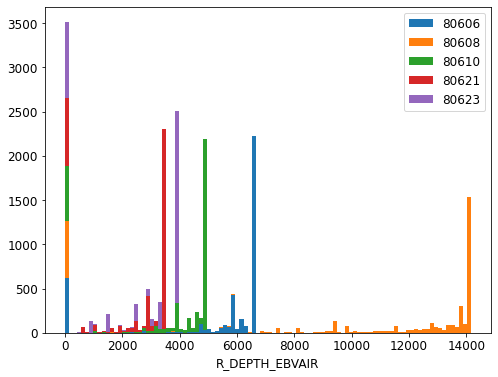

In [8]:
plt.figure(figsize=(8, 6))
tileid_list = np.unique(zbest['TILEID'])
tmp = []
for tileid in tileid_list:
    mask = zbest['TILEID']==tileid
    tmp.append(zbest['R_DEPTH_EBVAIR'][mask])
plt.hist(tmp, 100, label=tileid_list, range=(0, zbest['R_DEPTH_EBVAIR'].max()), histtype='barstacked')
plt.xlabel('R_DEPTH_EBVAIR')
plt.legend()
plt.show()

In [9]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = zbest['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 16870 3512 0.17230890000981258
No data 16870 0 0.0
9510 7360 0.5637225844694724
9510


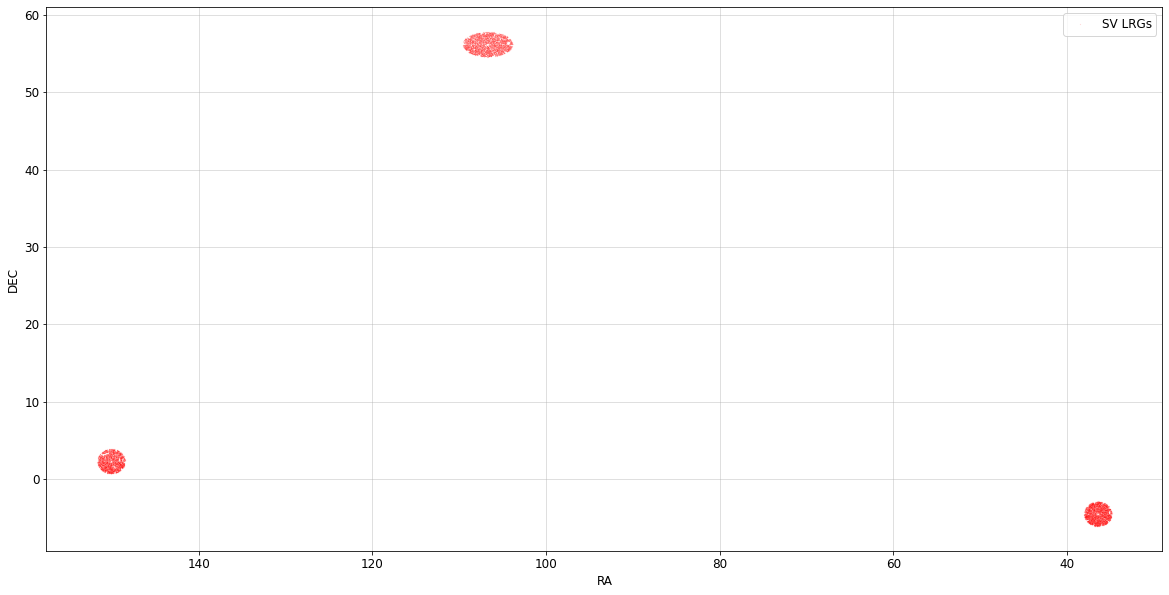

In [11]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()